In [1]:
## tools
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

/home/pranav/agentic/venv/lib64/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [21]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=5, doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv Papers")

print(arxiv.name)

arxiv


In [25]:
arxiv.invoke("quantum computing")

'Published: 2022-11-04\nTitle: Tierkreis: A Dataflow Framework for Hybrid Quantum-Classical Computing\nAuthors: Seyon Sivarajah, Lukas Heidemann, Alan Lawrence, Ross Duncan\nSummary: We present Tierkreis, a higher-order dataflow graph program representation and runtime designed for compositional, quantum-classical hybrid algorithms. The design of the system is motivated by the remote nature of quantum computers, the need for hybrid algorithms to involve cloud and distributed computing, and the long-'

In [26]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [27]:
wiki.invoke("India")

"Page: India\nSummary: India, officially the Republic of India, is a country in South Asia.  It is the seventh-largest country by area; the most populous country since 2023; and, since its independence in 1947, the world's most populous democracy. Bounded by the Indian Ocean on the south, the Arabian Sea on the southwest, and the Bay of Bengal on the southeast, it shares land borders with Pakistan to the west; China, Nepal, and Bhutan to the north; and Bangladesh and Myanmar to the east. In the In"

In [28]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [10]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()


/tmp/ipykernel_52287/819491451.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [11]:
tavily.invoke("Provide me the recent iserael iran news")

[{'title': 'Latest news on the U.S.-Israeli war with Iran — stories, videos, latest coverage',
  'url': 'https://www.cbsnews.com/us-iran-tensions/',
  'content': 'Economic forecasts show that this week\'s March Consumer Price Index could show prices climbing at their fastest pace in nearly two years.\n\nRelief efforts continue in Beirut hit by intense Israeli attacks \n\n#### Israel\'s war in Lebanon has become a flashpoint for the Iran ceasefire\n\nThe U.S. and Israel publicly disagree with Iran and Pakistan over whether the country to Israel\'s north is included in the Iran ceasefire.\n\nSite of Israeli strike in Tyre \n\n#### Iran accuses U.S. of violating ceasefire amid Israeli attacks on Lebanon\n\nIran says Israel is violating the ceasefire deal President Trump announced, and Tehran appears to still have control over shipping in the Strait of Hormuz.\n\nJD Vance Supports Viktor Orbán Election Campaign In Budapest [...] The following is the full transcript of an interview with Kri

In [13]:
tools = [arxiv, wiki, tavily]

In [15]:
##initialise the llms models

from langchain_groq import ChatGroq

llm = ChatGroq(model = "qwen/qwen3-32b", )

In [16]:
llm.invoke("what is ai?")

AIMessage(content='<think>\nOkay, the user is asking "what is AI?" Let me start by breaking down the question. They probably want a basic definition but might also be interested in examples or how it\'s used today.\n\nFirst, I should define AI as the simulation of human intelligence by machines. But maybe I should mention that it\'s a broad field, not just one technology. Then, I need to explain the key concepts like learning from data, problem-solving, and adapting.\n\nI should differentiate between narrow AI, which is what we have now, and general AI, which is still theoretical. Examples would help here, like Siri or recommendation systems. Also, mentioning machine learning and deep learning as subsets could clarify the technical aspects.\n\nThe user might not know the difference between AI and other terms like machine learning, so I should address that. Applications are important too—healthcare, finance, etc.—to show real-world impact. Ethical considerations are also relevant these 

In [17]:
llm_with_tools = llm.bind_tools(tools=tools)


In [19]:
llm_with_tools.invoke("rohan bhati linkedin id mnit jaipur search")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the LinkedIn ID of Rohan Bhati from MNIT Jaipur. Let me break this down. First, I need to confirm if Rohan Bhati is a real person associated with MNIT Jaipur. MNIT stands for Malaviya National Institute of Technology, Jaipur. It\'s a well-known engineering college, so the name is likely correct.\n\nNext, the user wants a LinkedIn ID. LinkedIn IDs are usually the unique identifiers in a person\'s profile URL. For example, if someone\'s profile is linkedin.com/in/johndoe123, their LinkedIn ID is johndoe123. So, the user probably wants the username part of the LinkedIn URL.\n\nSince the user is asking for a specific person\'s LinkedIn ID, I need to find a reliable source to get that information. The functions available are arxiv, wikipedia, and tavily_search_results_json. \n\nArxiv is for academic papers, so that\'s probably not useful here. Wikipedia is for general knowledge and biographies, but u

## workflow

In [30]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated # labeling
from langgraph.graph.message import add_messages # reducer in langgraph

In [31]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage], add_messages]


In [32]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [33]:
def tool_calling_llm(state:State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

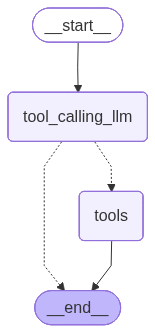

In [34]:
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)

graph = builder.compile()
display(graph)

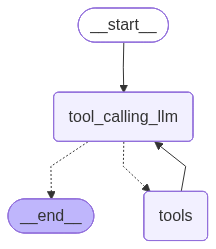

In [35]:
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()
display(graph)

In [41]:
messages = graph.invoke({"messages":"leetcode divyansh pokharna how many questions he has done? he is from mnit jaipur. if you cannot find how many quesions he has done give me his leetcode id. you should search it on interent"})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

leetcode divyansh pokharna how many questions he has done? he is from mnit jaipur. if you cannot find how many quesions he has done give me his leetcode id. you should search it on interent
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (8xdqzvbw9)
 Call ID: 8xdqzvbw9
  Args:
    query: Divyansh Pokharna LeetCode profile MNIT Jaipur
================================= Tool Message =================================
Name: tavily_search_results_json

ConnectionError(MaxRetryError('HTTPSConnectionPool(host=\'api.tavily.com\', port=443): Max retries exceeded with url: /search (Caused by NameResolutionError("HTTPSConnection(host=\'api.tavily.com\', port=443): Failed to resolve \'api.tavily.com\' ([Errno -5] No address associated with hostname)"))'))
================================== Ai Message ==================================

I was una

In [36]:
messages

{'messages': [HumanMessage(content='1706.03762', additional_kwargs={}, response_metadata={}, id='5c055ec4-4cea-437c-a859-9e063cc4c50c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user provided the number 1706.03762. Let me figure out what they need.\n\nFirst, that number looks like an arXiv paper ID. ArXiv IDs usually start with the year and month, so 1706 would be June 2017. The full ID is 1706.03762. The user might want information about this specific paper. \n\nLooking at the tools available, there's an arXiv function that takes a query. So I should use that function to get details about this paper. The parameters require a query string. I'll input the ID as the query. \n\nI should check if there's any other possible interpretation, but given the format, it's safe to assume it's an arXiv ID. No need for other tools like Wikipedia or Tavily here. \n\nSo the correct function to call is arxiv with the query parameter set to 1706.03762.\n", 'tool_calls':

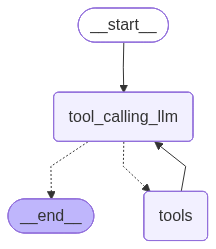

In [39]:
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph1 = builder.compile()
display(graph1)

In [43]:
messages = graph1.invoke({"messages":"what is the recent ai news can you tell me that and also please tell me recent recerch on quantum computing."})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news can you tell me that and also please tell me recent recerch on quantum computing.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (b48e28ymh)
 Call ID: b48e28ymh
  Args:
    query: latest AI news 2024
  arxiv (xhf90523k)
 Call ID: xhf90523k
  Args:
    query: recent quantum computing research
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI 2024 in review: The 10 most notable AI stories of the year", "url": "https://iot-analytics.com/ai-2024-10-most-notable-stories/", "content": "LLaMa 3.1 either on par with or outperforms ChatGPT or Claude models. On July 13, 2024, Meta introduced its updated LLaMA 3.1 (short for Large Language Model Meta AI, offered open weight under a noncommercial license) and released results of the model